# Top Players
A scouting report to find the best players of each positions

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine

load_dotenv()

engine = create_engine(
    URL.create(
        "postgresql+psycopg",
        username=os.environ["POSTGRES_USER"],
        password=os.environ["POSTGRES_PASSWORD"],
        host=os.environ["POSTGRES_HOST"],
        port=int(os.environ["POSTGRES_PORT"]),
        database=os.environ["POSTGRES_DB"],
    )
)

In [2]:
query = """
SELECT * FROM marts.player_scouting
WHERE season = '2026/27'
"""

stats = pd.read_sql(query, engine)
stats.shape

(667, 21)

In [3]:
MIN_MINUTES = 270


def top(position, sort_by, columns, ascending=False, min_minutes=MIN_MINUTES, n=20):
    sort_by = [sort_by] if isinstance(sort_by, str) else list(sort_by)
    ascending = [ascending] * len(sort_by) if isinstance(ascending, bool) else list(ascending)
    players = stats[(stats["position"] == position) & (stats["minutes"] >= min_minutes)]
    table = players.sort_values([*sort_by, "web_name"], ascending=[*ascending, True]).head(n)
    table = table[["web_name", "team", "price", "minutes", *columns]].reset_index(drop=True)
    table.index += 1
    return table

## Goalkeepers

### xGc/90

In [4]:
top("GKP", "xgc_per_90", ["xgc_per_90", "clean_sheets", "saves", "total_points"], ascending=True)

,web_name,team,price,minutes,xgc_per_90,clean_sheets,saves,total_points
1,Raya,ARS,6.1,450,0.81,3,9,30
2,Sels,NFO,5.0,450,0.95,1,11,14
3,A.Becker,LIV,5.5,450,1.22,3,14,27
4,Kelleher,BRE,5.0,450,1.26,2,17,20
5,Trafford,LEE,5.0,450,1.29,2,20,28
6,Lammens,MUN,4.9,450,1.36,0,16,11
7,Suzuki,AVL,5.0,360,1.36,1,15,16
8,Petrović,BOU,4.5,450,1.39,0,11,9
9,Pickford,EVE,5.5,450,1.39,3,15,25
10,Donnarumma,MCI,5.5,450,1.45,2,14,19


### Points/mil

In [5]:
top("GKP", "points_per_million", ["total_points", "points_per_million"], ascending=False)

,web_name,team,price,minutes,total_points,points_per_million
1,Tzolakis,HUL,4.7,450,34,7.2
2,Trafford,LEE,5.0,450,28,5.6
3,Verbruggen,BHA,4.5,450,23,5.1
4,A.Becker,LIV,5.5,450,27,4.9
5,Raya,ARS,6.1,450,30,4.9
6,Pickford,EVE,5.5,450,25,4.5
7,Kelleher,BRE,5.0,450,20,4.0
8,Kinsky,TOT,4.5,450,18,4.0
9,Leno,FUL,4.5,450,18,4.0
10,Rushworth,COV,4.5,450,16,3.6


## Defenders

### xGI/90

In [6]:
top("DEF", ["xgi_per_90", "xgi"], ["xgi_per_90", "xgi", "total_points"], False)

,web_name,team,price,minutes,xgi_per_90,xgi,total_points
1,De Cuyper,BHA,5.0,423,0.47,2.22,38
2,Davis,IPS,4.0,450,0.41,2.05,25
3,Bogle,LEE,4.6,365,0.36,1.46,42
4,Khalaili,CRY,5.0,379,0.31,1.29,19
5,Kayode,BRE,4.6,294,0.30,0.98,23
6,Calafiori,ARS,5.8,416,0.28,1.29,29
7,Guéhi,MCI,6.0,450,0.27,1.34,30
8,Mukiele,SUN,5.4,360,0.26,1.03,13
9,Silva,BOU,5.0,450,0.23,1.14,13
10,Castagne,FUL,4.5,408,0.23,1.06,20


### Defcon/90

In [7]:
top("DEF", ["defcon_per_90", "defcon"], ["defcon_per_90", "defcon", "defcon_hits", "defcon_hit_rate"], False)

,web_name,team,price,minutes,defcon_per_90,defcon,defcon_hits,defcon_hit_rate
1,Pinnock,COV,4.5,282,14.0,44,3,0.75
2,Fofana,CHE,5.0,312,13.6,47,2,0.50
3,Egan,HUL,4.1,437,12.2,59,3,0.60
4,Mukiele,SUN,5.4,360,12.0,48,2,0.50
5,Botman,NEW,5.0,450,11.8,59,3,0.60
6,Muharemović,LEE,5.0,450,11.6,58,3,0.60
7,Lacroix,CHE,5.9,364,11.6,47,3,0.60
8,Silva,BOU,5.0,450,11.2,56,4,0.80
9,Branthwaite,EVE,5.5,450,10.8,54,3,0.60
10,Richards,CRY,4.9,450,10.8,54,3,0.60


### Points/mil

In [8]:
top("DEF", "points_per_million", ["total_points", "points_per_million"], ascending=False)

,web_name,team,price,minutes,total_points,points_per_million
1,Bogle,LEE,4.6,365,42,9.1
2,De Cuyper,BHA,5.0,423,38,7.6
3,Tarkowski,EVE,6.2,450,43,6.9
4,Gvardiol,MCI,5.7,434,37,6.5
5,Ajayi,HUL,4.2,423,27,6.4
6,Vuskovic,BHA,5.0,437,32,6.4
7,Davis,IPS,4.0,450,25,6.3
8,Egan,HUL,4.1,437,26,6.3
9,Giles,HUL,4.0,444,24,6.0
10,Thomas,COV,4.0,437,24,6.0


## Midfielders

### xGI/90

In [9]:
top("MID", ["xgi_per_90", "xgi"], ["xgi_per_90", "xgi", "total_points"], False)

,web_name,team,price,minutes,xgi_per_90,xgi,total_points
1,Saka,ARS,9.5,416,0.91,4.20,32
2,B.Fernandes,MUN,11.9,450,0.78,3.88,31
3,Mbeumo,MUN,7.9,450,0.77,3.87,25
4,E.Le Fée,SUN,5.7,438,0.70,3.40,18
5,Cherki,MCI,7.8,302,0.67,2.26,34
6,Ndoye,NFO,5.5,316,0.62,2.18,15
7,Rudoni,COV,4.9,297,0.62,2.03,13
8,Rogers,CHE,7.7,437,0.61,2.95,29
9,Gibbs-White,NFO,8.0,450,0.60,2.98,28
10,Ødegaard,ARS,6.8,377,0.57,2.40,29


### Defcon/90

In [10]:
top("MID", ["defcon_per_90", "defcon"], ["defcon_per_90", "defcon", "defcon_hits", "defcon_hit_rate"], False)

,web_name,team,price,minutes,defcon_per_90,defcon,defcon_hits,defcon_hit_rate
1,Bentancur,TOT,5.5,370,14.6,60,2,0.4
2,Palacios,IPS,5.0,275,14.4,44,2,0.5
3,Mainoo,MUN,5.5,354,14.2,56,4,0.8
4,Charles,FUL,5.0,303,13.7,46,2,0.4
5,M.Sangaré,BRE,5.6,321,13.5,48,3,0.6
6,Adams,BOU,5.0,279,13.2,41,2,0.4
7,Janelt,BRE,5.0,450,12.8,64,3,0.6
8,Stach,LEE,6.0,447,12.3,61,3,0.6
9,Garner,EVE,6.0,328,12.3,45,1,0.2
10,Scott,BOU,6.1,446,12.1,60,2,0.4


### Points/mil

In [11]:
top("MID", "points_per_million", ["total_points", "points_per_million"], ascending=False)

,web_name,team,price,minutes,total_points,points_per_million
1,Groß,BHA,5.8,450,47,8.1
2,Schade,BRE,6.2,447,39,6.3
3,Belloumi,HUL,5.1,394,31,6.1
4,Janelt,BRE,5.0,450,28,5.6
5,Tavernier,BOU,6.1,424,31,5.1
6,Scott,BOU,6.1,446,30,4.9
7,Gomez,BHA,5.0,433,24,4.8
8,Barnes,NEW,6.1,450,28,4.6
9,Stach,LEE,6.0,447,27,4.5
10,Cherki,MCI,7.8,302,34,4.4


## Forwards

### xGI/90

In [12]:
top("FWD", ["xgi_per_90", "xgi"], ["xgi_per_90", "xgi", "total_points"], False)

,web_name,team,price,minutes,xgi_per_90,xgi,total_points
1,Haaland,MCI,15.6,450,0.99,4.95,39
2,Barry,EVE,5.7,417,0.79,3.65,20
3,Isak,LIV,9.1,413,0.79,3.62,33
4,Brobbey,SUN,5.7,399,0.69,3.05,24
5,Thiago,BRE,7.8,442,0.67,3.29,10
6,Calvert-Lewin,LEE,6.0,419,0.66,3.08,22
7,Gonzalo,FUL,6.0,425,0.62,2.91,14
8,João Pedro,CHE,7.7,360,0.59,2.36,33
9,Wissa,NEW,6.2,441,0.49,2.41,15
10,Emersonn,IPS,5.5,317,0.49,1.73,26


### Points/mil

In [13]:
top("FWD", "points_per_million", ["total_points", "points_per_million"], ascending=False)

,web_name,team,price,minutes,total_points,points_per_million
1,Kostoulas,BHA,5.6,353,28,5.0
2,Emersonn,IPS,5.5,317,26,4.7
3,João Pedro,CHE,7.7,360,33,4.3
4,Brobbey,SUN,5.7,399,24,4.2
5,Calvert-Lewin,LEE,6.0,419,22,3.7
6,Isak,LIV,9.1,413,33,3.6
7,Barry,EVE,5.7,417,20,3.5
8,Evanilson,BOU,6.0,424,18,3.0
9,Haaland,MCI,15.6,450,39,2.5
10,Havertz,ARS,7.6,437,19,2.5


## Plots

### Defcon/90 vs the points threshold

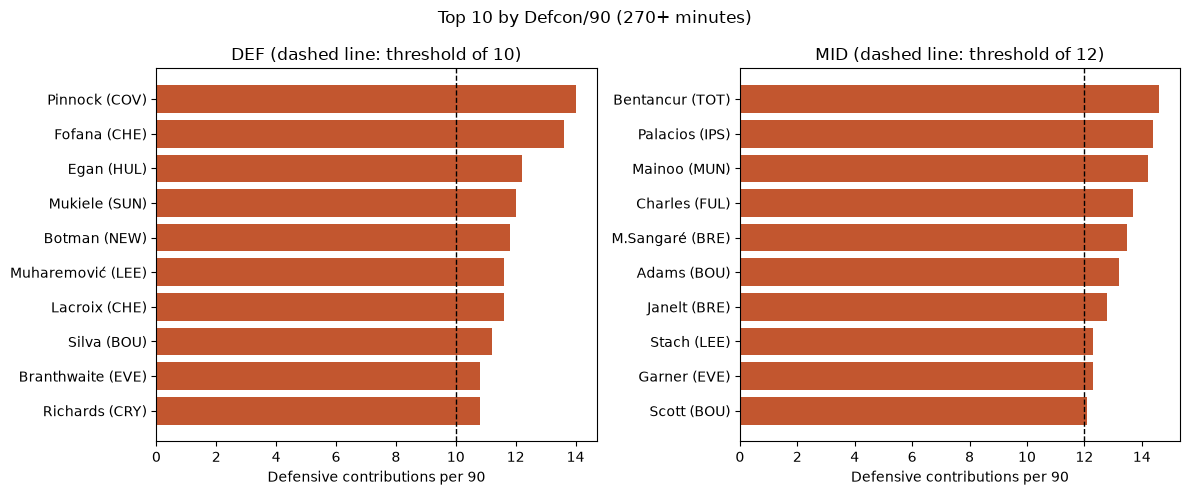

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, position, threshold in [(axes[0], "DEF", 10), (axes[1], "MID", 12)]:
    table = top(position, ["defcon_per_90", "defcon"], ["defcon_per_90"], min_minutes=MIN_MINUTES, n=10)
    ax.barh(table["web_name"] + " (" + table["team"] + ")", table["defcon_per_90"], color="#c2562f")
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1)
    ax.invert_yaxis()
    ax.set_title(f"{position} (dashed line: threshold of {threshold})")
    ax.set_xlabel("Defensive contributions per 90")
fig.suptitle(f"Top 10 by Defcon/90 ({MIN_MINUTES}+ minutes)")
fig.tight_layout()
plt.show()

### Actual vs expected
Season totals for the same top 20 as the tables above: goalkeepers by xGC/90, outfield players by xGI/90. On the dotted line, actual = expected. Goalkeepers below it conceded fewer goals than xGC. Outfield players above it have more goals + assists than xGI.

In [15]:
AXIS_LABELS = {
    "xgc": "Expected goals conceded (xGC)",
    "goals_conceded": "Goals conceded",
    "xgi": "Expected goal involvements (xGI)",
    "gi": "Goals + assists",
}


def actual_vs_expected(players, expected, actual, title, above, below):
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.scatter(players[expected], players[actual], color="#c2562f", zorder=3)
    limit = max(players[expected].max(), players[actual].max()) * 1.1
    ax.plot([0, limit], [0, limit], color="black", linestyle=":", linewidth=1)
    ax.set_xlim(-limit * 0.05, limit)
    ax.set_ylim(-limit * 0.05, limit)
    ax.set_aspect("equal")
    ax.text(0.02, 0.98, above, transform=ax.transAxes, va="top", color="grey")
    ax.text(0.98, 0.02, below, transform=ax.transAxes, ha="right", color="grey")
    ax.set_title(f"{title} ({len(players)} players)")
    ax.set_xlabel(AXIS_LABELS[expected])
    ax.set_ylabel(AXIS_LABELS[actual])
    labels = [
        ax.text(x, y, name, fontsize=8)
        for x, y, name in zip(players[expected], players[actual], players["web_name"])
    ]
    adjust_text(
        labels,
        x=players[expected].tolist(),
        y=players[actual].tolist(),
        ax=ax,
        expand=(1.6, 2.0),
        max_move=None,
        arrowprops=dict(arrowstyle="-", color="grey", linewidth=0.5),
    )
    plt.show()

### Goalkeepers: goals conceded vs xGC

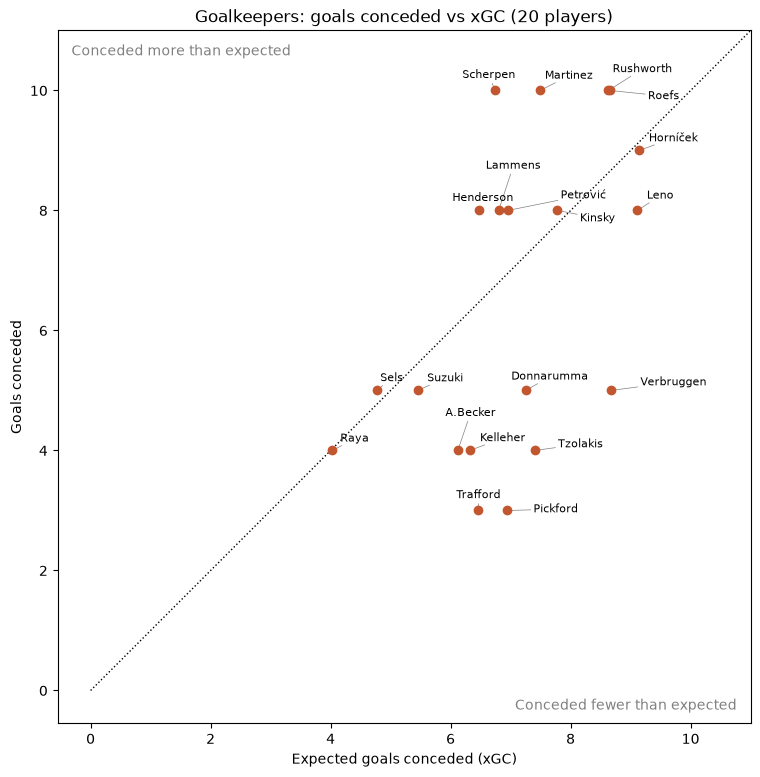

In [16]:
keepers = top("GKP", "xgc_per_90", ["xgc", "goals_conceded"], ascending=True)
actual_vs_expected(
    keepers,
    expected="xgc",
    actual="goals_conceded",
    title="Goalkeepers: goals conceded vs xGC",
    above="Conceded more than expected",
    below="Conceded fewer than expected",
)

### Defenders: goals + assists vs xGI

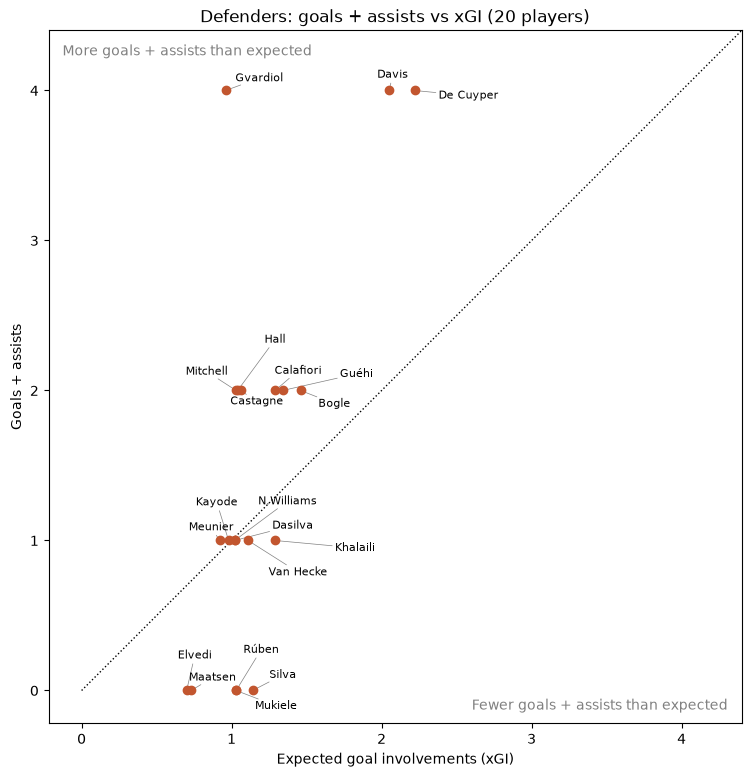

In [17]:
defenders = top("DEF", ["xgi_per_90", "xgi"], ["xgi", "gi"])
actual_vs_expected(
    defenders,
    expected="xgi",
    actual="gi",
    title="Defenders: goals + assists vs xGI",
    above="More goals + assists than expected",
    below="Fewer goals + assists than expected",
)

### Midfielders: goals + assists vs xGI

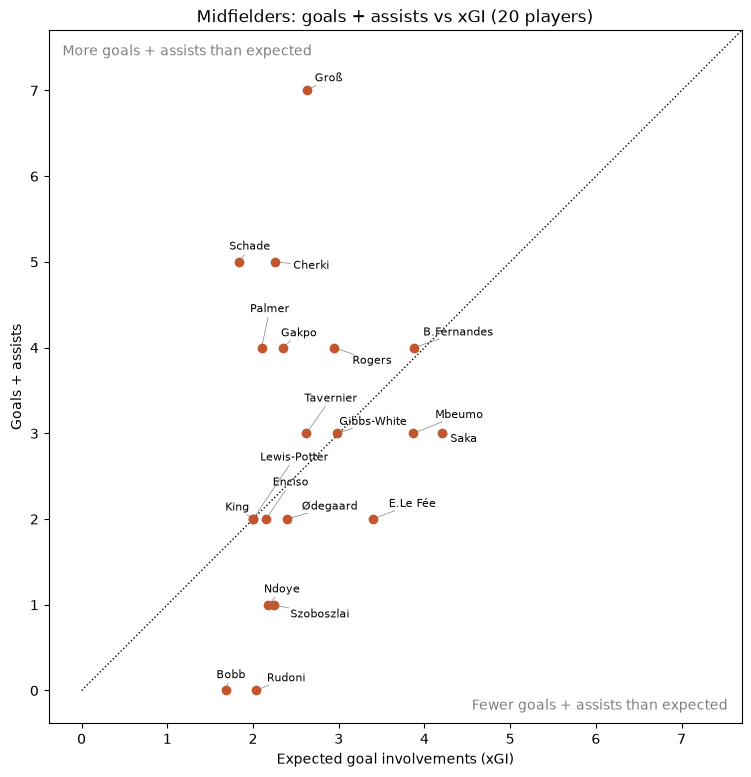

In [18]:
midfielders = top("MID", ["xgi_per_90", "xgi"], ["xgi", "gi"])
actual_vs_expected(
    midfielders,
    expected="xgi",
    actual="gi",
    title="Midfielders: goals + assists vs xGI",
    above="More goals + assists than expected",
    below="Fewer goals + assists than expected",
)

### Forwards: goals + assists vs xGI

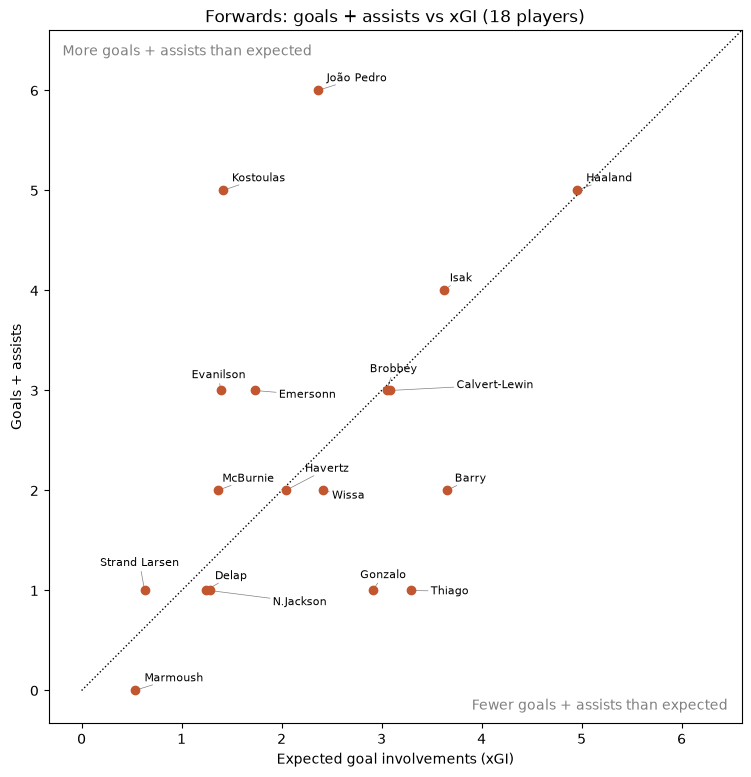

In [19]:
forwards = top("FWD", ["xgi_per_90", "xgi"], ["xgi", "gi"])
actual_vs_expected(
    forwards,
    expected="xgi",
    actual="gi",
    title="Forwards: goals + assists vs xGI",
    above="More goals + assists than expected",
    below="Fewer goals + assists than expected",
)